In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re

import ipycytoscape


from pyvis.network import Network
import os


DEBUG = True
SAVE_PATH = "timeseries_GMAN_model.pth"

In [2]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

    """
    Visualizes a networkx Graph with flow values from a pandas Series.
    
    Parameters:
    - G: networkx.Graph or DiGraph
    - flow_series: pd.Series where index is edges (u,v) and values are floats.
    """
    
    # 1. Setup Figure
    plt.figure(figsize=(14, 10), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # 2. Generate "Spread" Layout
    # We scale 'k' (repulsive force) based on node count to keep it sparse
    k_val = 2.0 / np.sqrt(len(G.nodes())) if len(G.nodes()) > 0 else 1
    pos = nx.spring_layout(G, k=k_val, iterations=50, seed=42)

    # 3. Process Edge Styles
    edge_colors = []
    edge_widths = []
    edge_labels = {}
    
    # Handle empty series or all zeros
    if flow_series.empty:
        max_val = 1.0
    else:
        max_val = flow_series.max()
        if max_val == 0: max_val = 1.0

    for u, v in G.edges():
        # Retrieve flow safely, checking both (u,v) and (v,u)
        val = 0.0
        if (u, v) in flow_series.index:
            val = flow_series.loc[(u, v)]
        elif (v, u) in flow_series.index:
            val = flow_series.loc[(v, u)]
        
        # Color: Map value directly
        edge_colors.append(val)
        
        # Width: Base width (1.0) + scaled extra width (up to 6.0)
        width_scale = 1.0 + (val / max_val) * 6.0
        edge_widths.append(width_scale)
        
        # Label: formatted string
        edge_labels[(u, v)] = f"{val:.1f}"

    # 4. Draw Components
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightgrey', edgecolors='black')
    
    # Draw Node Labels
    nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold')

    # Draw Edges
    # We use a colormap (Blues) to visualize intensity
    cmap = plt.cm.Blues
    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           edge_color=edge_colors, 
                           edge_cmap=cmap, 
                           edge_vmin=0, 
                           edge_vmax=max_val,
                           arrows=True, arrowstyle='-|>', arrowsize=20)
    
    # Draw Flow Values (with white background for readability)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_color='black', font_size=10,
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

    # 5. Add Colorbar (Robust Method)
    # Create a 'ScalarMappable' explicitly to avoid AttributeError
    norm = mcolors.Normalize(vmin=0, vmax=max_val)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Flow Magnitude', color='black', size=12)
    cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')

    # 6. Final Polish
    plt.title(title, fontsize=16, color='black')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_specific_flow(flow_dict):
    # 2. Reconstruct the Graph from the keys
    G = nx.DiGraph()
    G.add_edges_from(flow_dict.keys())
    
    # 3. Auto-detect Sources and Sinks
    # Sources = Nodes with In-Degree 0
    sources = [n for n in G.nodes if G.in_degree(n) == 0]
    # Sinks = Nodes with Out-Degree 0
    sinks = [n for n in G.nodes if G.out_degree(n) == 0]
    
    print(f"Detected Sources (Inputs): {sources}")
    print(f"Detected Sinks (Outputs): {sinks}")
    
    results = []
    
    # 4. Calculate Balance for Internal Nodes
    for node in G.nodes:
        if node in sources or node in sinks:
            continue
            
        flow_in = 0.0
        flow_out = 0.0
        
        # Sum Inputs
        for u in G.predecessors(node):
            flow_in += flow_dict.get((u, node), 0.0)
            
        # Sum Outputs
        for v in G.successors(node):
            flow_out += flow_dict.get((node, v), 0.0)
            
        balance = flow_in - flow_out
        
        # Determine status
        if abs(balance) < 1e-4:
            status = "✅ Balanced"
        elif balance > 0:
            status = "⚠️ Accumulation (In > Out)"
        else:
            status = "🔻 Leak/Gain (Out > In)" # Out is higher, so flow appeared
            
        results.append({
            "Node": node,
            "Flow In": round(flow_in, 3),
            "Flow Out": round(flow_out, 3),
            "Diff": round(balance, 3),
            "Status": status
        })
        
    #return pd.DataFrame(results).set_index("Node")
    return pd.DataFrame(results).set_index("Node").Diff.mean()

    """
    Generates a dynamic HTML graph from a dictionary of edge flows.
    
    Args:
        flow_dict (dict): Format {(Source, Target): flow_value}
        output_file (str): Name of the output HTML file.
        show_buttons (bool): If True, adds a UI to tweak physics/layout.
    """
    
    # 1. Initialize the NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Track min/max flow for normalization (to scale edge thickness)
    flows = list(flow_dict.values())
    if not flows:
        print("Dictionary is empty.")
        return
        
    min_flow = min(flows)
    max_flow = max(flows)
    
    # Avoid division by zero if all flows are the same
    norm_range = max_flow - min_flow if max_flow != min_flow else 1

    # 2. Build the graph
    for (source, target), flow in flow_dict.items():
        # Calculate distinct visual weight (scale between 1 and 10)
        # Formula: 1 + ((flow - min) / range) * 9
        visual_width = 1 + ((flow - min_flow) / norm_range) * 9
        
        G.add_edge(
            source, 
            target, 
            value=flow,           # Stored metadata
            title=f"Flow: {flow}", # Tooltip on hover
            label=str(flow),      # Text on the arrow
            width=visual_width,   # Thickness of the line
            arrowStrikethrough=False
        )

    # 3. Initialize PyVis Network
    # height/width '100%' makes it fill the browser window
    net = Network(height="750px", width="100%", directed=True, notebook=False)
    
    # 4. Load the NetworkX graph into PyVis
    net.from_nx(G)

    # 5. Customize Physics and Appearance
    # This sets a specific physics layout that spreads nodes nicely
    net.barnes_hut(gravity=-2000, central_gravity=0.3, spring_length=95)
    
    if show_buttons:
        # Adds a control panel to the UI to play with layout physics dynamically
        net.show_buttons(filter_=['physics'])

    # 6. Save/Show result
    # We use write_html to ensure compatibility across environments
    net.write_html(output_file)
    
    print(f"Graph successfully generated: {os.path.abspath(output_file)}")
    # If you are in Jupyter, you can return IFrame or let it display:
    # return net.show(output_file)

def visualize_flow_series(data:pd.Series):
    G_vis = nx.DiGraph()
    for k,v in data.items():
        G_vis.add_edge(k[0],k[1],weight=round(v,1))
        
    cyto = ipycytoscape.CytoscapeWidget()
    cyto.graph.add_graph_from_networkx(G_vis)

    cyto.set_style([
        {
            'selector': 'node',
            'style': {
                'label': 'data(id)',
                'background-color': '#0074D9',
                'color': 'white',
                'text-valign': 'center',
                'text-halign': 'center',
                'width': '40px',
                'height': '40px',
                'font-size': '15px',
            }
        },
        {
            'selector': 'edge',
            'style': {
                'label': 'data(weight)',  
                'width': 'mapData(weight, 0, 10, 1, 8)',
                'line-color': '#9dbaea',
                'target-arrow-shape': 'triangle',
                'curve-style': 'bezier',
                'font-size': '15px',
                'color': '#555'
            }
        }
    ])

    # 4. Configure "Gravity" (Repulsion)
    # 'nodeRepulsion' controls how much they push away from each other
    cyto.set_layout(
        name='cose',
        nodeRepulsion=400000, 
        idealEdgeLength=100,
        gravity=80
    )

    cyto.layout.width = '100%'   
    cyto.layout.height = '600px'

    return cyto


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
#display(DEMANDS.plot(figsize=(20,10)))


RAW_DATA = pd.DataFrame()
for k,v in DEMANDS.iterrows():
    _flow = calculate_edge_flows(G, v.to_dict() )
    _flow.columns = [k]   
    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)

clear_output()

# SIULATING NOISE
NOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)

#display(RAW_DATA.T.plot(figsize=(20,10)))

timestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]
print()
visualize_flow_series(RAW_DATA.loc[:,timestamp])



CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

<Axes: >

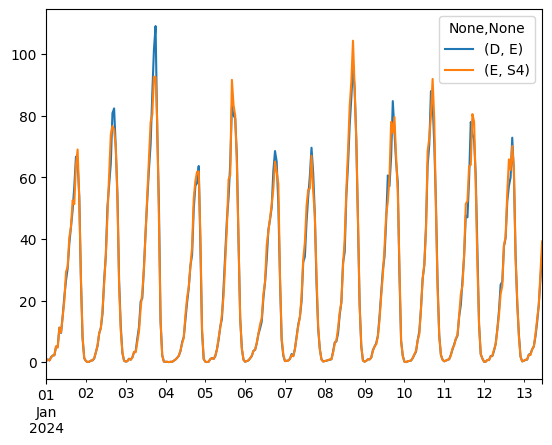

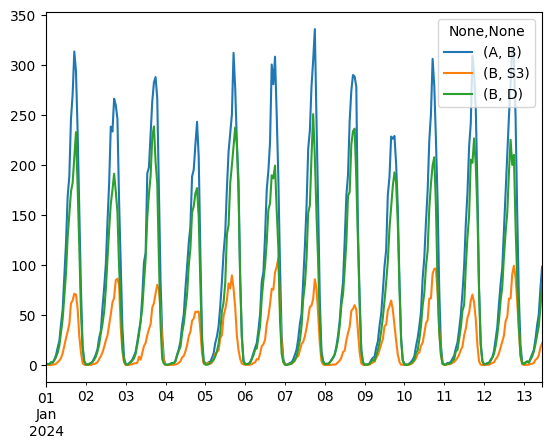

In [3]:
RAW_DATA.loc[[('D','E'),('E','S4')]].iloc[:,:300].T.plot()
RAW_DATA.loc[[('A','B'),('B','S3'),('B','D')]].iloc[:,:300].T.plot()

## PREPARATION OF DATA

In [97]:
SAMPLING = '1h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS = TSS[TSS.index.month.isin(TSS.index.month.unique()[-8:])]
TSS

HR_A MR_B       MR_A        HR_B        MR_B  \
                          MR_A MR_A          C        MR_B           A   
2024-01-01 00:00:00   0.324414  0.0   0.339985    1.553115    1.284016   
2024-01-01 01:00:00   0.000000  0.0   0.000000    1.427735    1.450812   
2024-01-01 02:00:00   0.000000  0.0   0.000000    1.309550    1.335443   
2024-01-01 03:00:00   0.000000  0.0   0.000000    3.513454    2.985588   
2024-01-01 04:00:00   2.300104  0.0   2.236123    4.558713    4.093993   
...                        ...  ...        ...         ...         ...   
2024-06-28 19:00:00  69.579970  0.0  72.298671  310.449117  289.404924   
2024-06-28 20:00:00  44.812780  0.0  47.377897  181.551518  176.709039   
2024-06-28 21:00:00  16.330408  0.0  16.989157   78.273992   82.081112   
2024-06-28 22:00:00   5.384770  0.0   5.468039   29.588705   29.906199   
2024-06-28 23:00:00   0.785784  0.0   0.863800    6.417401    5.971051   

                            C           B          C          D             \
                            D           D         S7          E         S6   
2024-01-01 00:00:00  0.040194    0.659067   0.271369   0.324900   0.307609   
2024-01-01 01:00:00  0.000000    1.161686   0.000000   0.861233   0.247209   
2024-01-01 02:00:00  0.000000    0.804511   0.000000   0.517633   0.000000   
2024-01-01 03:00:00  0.000000    2.698047   0.000000   1.618083   0.791538   
2024-01-01 04:00:00  2.157388    2.284073   0.000000   2.123568   1.761868   
...                       ...         ...        ...        ...        ...   
2024-06-28 19:00:00  0.000000  162.913495  62.140066  38.076598  33.498972   
2024-06-28 20:00:00  0.000000   99.542039  44.984094  14.777236  11.289193   
2024-06-28 21:00:00  0.000000   47.325366  18.128957   3.283803   2.838181   
2024-06-28 22:00:00  0.000000   18.268461   5.249810   1.664803   0.635334   
2024-06-28 23:00:00  0.000000    3.198646   0.766364   0.105345   0.230939   

                                         A                                B  \
                            S5           B         S1         S2         S3   
2024-01-01 00:00:00   0.123435    0.733648   0.115213   0.407541   0.211918   
2024-01-01 01:00:00   0.000000    1.247211   0.000000   0.205097   0.110898   
2024-01-01 02:00:00   0.232038    0.942561   0.000000   0.417868   0.199481   
2024-01-01 03:00:00   0.336879    2.762788   0.227590   0.578412   0.000000   
2024-01-01 04:00:00   0.487262    2.748544   0.102593   1.312591   0.617467   
...                        ...         ...        ...        ...        ...   
2024-06-28 19:00:00  89.230956  226.733136  36.687585  38.748309  67.675289   
2024-06-28 20:00:00  75.023861  138.314356  17.956191  21.677829  45.263235   
2024-06-28 21:00:00  40.238539   64.518925   4.690115   8.169187  21.267225   
2024-06-28 22:00:00  15.971541   25.135023   0.645498   3.399803   7.726258   
2024-06-28 23:00:00   2.925917    6.108875   0.210417   0.256615   2.434674   

                             E  
                            S4  
2024-01-01 00:00:00   0.323767  
2024-01-01 01:00:00   0.797520  
2024-01-01 02:00:00   0.532207  
2024-01-01 03:00:00   1.433884  
2024-01-01 04:00:00   2.159369  
...                        ...  
2024-06-28 19:00:00  36.851088  
2024-06-28 20:00:00  14.463297  
2024-06-28 21:00:00   3.724638  
2024-06-28 22:00:00   1.579219  
2024-06-28 23:00:00   0.107616  

[4320 rows x 16 columns]

# GMAN

## ADJENCY MATRIX

In [98]:
G_orig = nx.DiGraph()

for v in TSS.columns:
    G_orig.add_edge(v[0],v[1])


G_links = nx.line_graph(G_orig)
ADJ_A = nx.to_numpy_array(G_links)
ADJ_A = ADJ_A + np.eye(ADJ_A.shape[0])


ADJ_DF = pd.DataFrame(ADJ_A, columns=G_links.nodes(), index=G_links.nodes())
ADJ_DF

HR_A MR_A    C      MR_B         A              D           HR_B  \
          MR_A    C    D   S7 MR_A    A    B   S1   S2    E   S6   S5 MR_B   
HR_A MR_A  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A C     0.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
C    D     0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0   
     S7    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B MR_A  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     A     0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0   
A    B     0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
     S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0   
D    E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0   
     S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0   
     S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
HR_B MR_B  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0   
B    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0   
     S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
E    S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

             B         E  
             D   S3   S4  
HR_A MR_A  0.0  0.0  0.0  
MR_A C     0.0  0.0  0.0  
C    D     0.0  0.0  0.0  
     S7    0.0  0.0  0.0  
MR_B MR_A  0.0  0.0  0.0  
     A     0.0  0.0  0.0  
A    B     1.0  1.0  0.0  
     S1    0.0  0.0  0.0  
     S2    0.0  0.0  0.0  
D    E     0.0  0.0  1.0  
     S6    0.0  0.0  0.0  
     S5    0.0  0.0  0.0  
HR_B MR_B  0.0  0.0  0.0  
B    D     1.0  0.0  0.0  
     S3    0.0  1.0  0.0  
E    S4    0.0  0.0  1.0

# DATA_PREPARATION

In [99]:
DATA_RAW_MODEL = TSS.copy()
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL

HR_A MR_B   MR_A    HR_B    MR_B     C       B      C  \
                      MR_A MR_A      C    MR_B       A     D       D     S7   
2024-01-01 00:00:00   0.32  0.0   0.34    1.55    1.28  0.04    0.66   0.27   
2024-01-01 01:00:00   0.00  0.0   0.00    1.43    1.45  0.00    1.16   0.00   
2024-01-01 02:00:00   0.00  0.0   0.00    1.31    1.34  0.00    0.80   0.00   
2024-01-01 03:00:00   0.00  0.0   0.00    3.51    2.99  0.00    2.70   0.00   
2024-01-01 04:00:00   2.30  0.0   2.24    4.56    4.09  2.16    2.28   0.00   
...                    ...  ...    ...     ...     ...   ...     ...    ...   
2024-06-28 19:00:00  69.58  0.0  72.30  310.45  289.40  0.00  162.91  62.14   
2024-06-28 20:00:00  44.81  0.0  47.38  181.55  176.71  0.00   99.54  44.98   
2024-06-28 21:00:00  16.33  0.0  16.99   78.27   82.08  0.00   47.33  18.13   
2024-06-28 22:00:00   5.38  0.0   5.47   29.59   29.91  0.00   18.27   5.25   
2024-06-28 23:00:00   0.79  0.0   0.86    6.42    5.97  0.00    3.20   0.77   

                         D                     A                    B      E  
                         E     S6     S5       B     S1     S2     S3     S4  
2024-01-01 00:00:00   0.32   0.31   0.12    0.73   0.12   0.41   0.21   0.32  
2024-01-01 01:00:00   0.86   0.25   0.00    1.25   0.00   0.21   0.11   0.80  
2024-01-01 02:00:00   0.52   0.00   0.23    0.94   0.00   0.42   0.20   0.53  
2024-01-01 03:00:00   1.62   0.79   0.34    2.76   0.23   0.58   0.00   1.43  
2024-01-01 04:00:00   2.12   1.76   0.49    2.75   0.10   1.31   0.62   2.16  
...                    ...    ...    ...     ...    ...    ...    ...    ...  
2024-06-28 19:00:00  38.08  33.50  89.23  226.73  36.69  38.75  67.68  36.85  
2024-06-28 20:00:00  14.78  11.29  75.02  138.31  17.96  21.68  45.26  14.46  
2024-06-28 21:00:00   3.28   2.84  40.24   64.52   4.69   8.17  21.27   3.72  
2024-06-28 22:00:00   1.66   0.64  15.97   25.14   0.65   3.40   7.73   1.58  
2024-06-28 23:00:00   0.11   0.23   2.93    6.11   0.21   0.26   2.43   0.11  

[4320 rows x 16 columns]

### PARAMETERS

In [210]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 60
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = ADJ_A.shape[0]
HIST_STEPS = int(1*(24/FREQ_H))          # 1 day
PRED_STEPS = int(1*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 64

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEAD = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEAD}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 24
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 64
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 16


### CREATE DATASET

In [211]:
from node2vec import Node2Vec
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset


In [212]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_hours=1, mean=None, std=None, is_inference=False):
        """
        dataframe:     Pandas DataFrame where Rows=Time, Cols=Nodes (Traffic Speed/Volume).
        num_his:       Number of historical steps (P).
        num_pred:      Number of prediction steps (Q).
        time_slot_min: Granularity of data in minutes (e.g., 5-minute intervals).
        mean, std:     Pre-calculated stats (pass these from the Training set when making Val/Test sets).
        """
        # Convert dataframe to numpy float32
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        self.is_inference = is_inference # Save the flag
        
        # --- 1. Create Temporal Embeddings (TE) ---
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate maximum steps per day based on granularity
        self.steps_per_day = (24) // time_slot_hours
        
        # Extract calendar features
        dow = time_index.dayofweek.values.reshape(-1, 1) # Day of Week (0-6)
        tod = ((time_index.hour) // time_slot_hours).values.reshape(-1, 1) # Time of Day (0 to steps_per_day-1)
        moy = time_index.month.values.reshape(-1, 1) # Month of Year (1-12)
        
        # Combine into a single matrix of shape [Total_Steps, 3]
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # --- 2. Normalize Data ---
        # If mean/std are provided (Validation/Test Set), use them.
        # If not (Training Set), calculate them per-node (axis=0).
        if mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            self.mean = np.mean(self.data, axis=0)
            self.std = np.std(self.data, axis=0)
            
        # Z-Score Normalization (StandardScaler logic)
        # Added 1e-5 to avoid division by zero if a node has constant values (std = 0)
        self.data = (self.data - self.mean) / (self.std + 1e-5)

    def __len__(self):
        # The number of valid sliding windows we can make
        if self.is_inference:
            return len(self.data) - self.num_his + 1 
        else:
            return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # --- Sliding Window Extraction ---
        
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding for both History and Future [P + Q, 3]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        # Convert to PyTorch Tensors. 
        # X and Y need a feature dimension at the end to match model expectations: [Steps, Nodes, 1]
        X = torch.tensor(X).unsqueeze(-1)

        if self.is_inference:
            TE = self.TE[idx : idx + self.num_his]
            TE = torch.tensor(TE)
            return X, TE # No Y returned

        Y = torch.tensor(Y).unsqueeze(-1)
        TE = torch.tensor(TE)
        
        return X, TE, Y

    def reverse_transform(self, x_scaled):
        """
        Reverses the Z-score normalization to get real-world units.
        Accepts: Numpy Arrays or PyTorch Tensors.
        """
        if torch.is_tensor(x_scaled):
            x_scaled = x_scaled.detach().cpu().numpy()

        # 1. Reshape the 1D stats [16] into 4D [1, 1, 16, 1] 
        # This forces the arrays to align perfectly with the [Batch, Time, Nodes, Features] shape
        mean_reshaped = self.mean.reshape(1, 1, -1, 1)
        std_reshaped = self.std.reshape(1, 1, -1, 1)
            
        # Broadcasting will automatically handle the shape correctly 
        # (e.g., applying 50 means to 50 nodes)
        return (x_scaled * std_reshaped) + mean_reshaped




if DEBUG:
    DATA_RAW_DS = NetworkTrafficDataset(
        dataframe=DATA_RAW_MODEL, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)


Dataset size: 4273
Data shape: torch.Size([24, 16, 1])
TE shape: torch.Size([48, 3])
Target shape: torch.Size([24, 16, 1])


In [213]:
def generate_node2vec_embeddings(adj_m, embedding_dim=64):
    """
    Generates node embeddings using Node2Vec.
    adj_matrix: (N, N) numpy array (adjacency matrix)
    """
    adj_matrix = adj_m


    # Create Graph
    rows, cols = np.where(adj_matrix > 0)
    G = nx.Graph() 
    for r, c in zip(rows, cols):
        G.add_edge(r, c, weight=adj_matrix[r, c])
        
    # Run Node2Vec
    # P=1, Q=1 is standard equivalent to DeepWalk, adjust for BFS/DFS bias
    node2vec = Node2Vec(G, dimensions=embedding_dim, walk_length=20, num_walks=200, workers=1, quiet=False)
    model = node2vec.fit(window=4, min_count=1, batch_words=4)
    
    # Extract vectors in order
    num_nodes = adj_matrix.shape[0]
    embeddings = np.zeros((num_nodes, embedding_dim))
    for i in range(num_nodes):
        if str(i) in model.wv:
            embeddings[i] = model.wv[str(i)]
        else:
            print(f"Node {i} not found in Node2Vec model")
            embeddings[i] = np.random.normal(0, 0.1, embedding_dim)
            
    return torch.tensor(embeddings, dtype=torch.float32)

if DEBUG:
    node_vectors = generate_node2vec_embeddings(ADJ_A, embedding_dim=D_MODEL)
    print(f"Node Vectors Shape: {node_vectors.shape}")

Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:00<00:00, 1176.19it/s]


Node Vectors Shape: torch.Size([16, 64])


### MODEL

In [214]:
class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        self.D = D
        
        # Spatial Embedding Projection
        self.se_fc = nn.Linear(D, D) # Input D (from Node2Vec) -> Output D
        
        # Temporal Embedding Projection
        # Features: DayOfWeek(7) + TimeOfDay(steps_per_day) + Month(12)
        self.te_dim = 7 + steps_per_day + 12
        self.te_fc = nn.Linear(self.te_dim, D)

    def forward(self, SE, TE):
        """
        SE: [Nodes, D] (Node2Vec weights)
        TE: [Batch, Total_Steps, 3] (Time Features)
        """
        # --- Spatial Part ---
        # SE: [N, D] -> [1, 1, N, D]
        se_emb = self.se_fc(SE).unsqueeze(0).unsqueeze(0)
        
        # --- Temporal Part ---
        # Extract features
        dow = F.one_hot(TE[..., 0].long() % 7, 7)
        tod = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        moy = F.one_hot(TE[..., 2].long() % 12, 12)
        
        # Concatenate: [Batch, Steps, Features]
        te_features = torch.cat([dow, tod, moy], dim=-1).float()
        
        # Project: [Batch, Steps, D]
        te_emb = self.te_fc(te_features)
        
        # Expand for broadcasting: [Batch, Steps, 1, D]
        te_emb = te_emb.unsqueeze(2)
        
        # --- Fusion ---
        # [1, 1, N, D] + [B, T, 1, D] = [B, T, N, D]
        return se_emb + te_emb

In [215]:
class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, mask=False):
        super(STAttBlock, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        self.d_head = d
        self.mask = mask
        
        # 1. Attention Modules (Native PyTorch)
        # batch_first=True expects [Batch, Seq_Len, Features]
        self.spatial_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                  num_heads=self.num_heads, 
                                                  batch_first=True)
        
        self.temporal_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                   num_heads=self.num_heads, 
                                                   batch_first=True)

        # 2. Gated Fusion (Learnable Weights)
        self.fc_xs = nn.Linear(self.d_model, self.d_model, bias=False)
        self.fc_xt = nn.Linear(self.d_model, self.d_model, bias=True)
        self.fc_h = nn.Linear(self.d_model, self.d_model)

        # 3. Normalization
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X, STE):
        """
        X: [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        """
        B, T, N, D = X.shape

        # --- SPATIAL ATTENTION (Nodes attend to Nodes) ---
        # We need Sequence = Nodes. So we combine Batch and Time.
        # Input Shape: [B*T, N, D]
        X_flat_s = X.reshape(B*T, N, D)
        STE_flat_s = STE.reshape(B*T, N, D)
        
        # Query = X + STE, Key = X + STE, Value = X
        query_s = X_flat_s + STE_flat_s
        
        # Native Attention
        # Output: [B*T, N, D]
        HS, _ = self.spatial_attn(query_s, query_s, X_flat_s)
        
        # Restore Shape: [B, T, N, D]
        HS = HS.reshape(B, T, N, D)

        # --- TEMPORAL ATTENTION (Time attends to Time) ---
        # We need Sequence = Time. So we combine Batch and Nodes.
        # Input Shape: [B*N, T, D]
        X_flat_t = X.permute(0, 2, 1, 3).reshape(B*N, T, D)
        STE_flat_t = STE.permute(0, 2, 1, 3).reshape(B*N, T, D)
        
        query_t = X_flat_t + STE_flat_t
        
        # Causal Masking (Optional)
        attn_mask = None
        if self.mask:
            # -inf mask for upper triangle (future)
            attn_mask = torch.triu(torch.ones(T, T) * float('-inf'), diagonal=1).to(X.device)
        
        # Native Attention
        # Output: [B*N, T, D]
        HT, _ = self.temporal_attn(query_t, query_t, X_flat_t, attn_mask=attn_mask)
        
        # Restore Shape: [B, N, T, D] -> [B, T, N, D]
        HT = HT.reshape(B, N, T, D).permute(0, 2, 1, 3)

        # --- GATED FUSION ---
        # z = sigmoid(HS*W1 + HT*W2)
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        H = self.fc_h(z * HS + (1 - z) * HT)
        
        # Residual Connection + Norm
        return self.norm(X + H)

if DEBUG:
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks

    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"X shape: {X.shape}")
    print(f"STE shape: {STE.shape}")
    
    block_masked = STAttBlock(K=K, d=d, bn_decay=0.1, mask=True)
    block_unmasked = STAttBlock(K=K, d=d, bn_decay=0.1, mask=False)

    # Test A: Masked (Encoder)
    out_masked = block_masked(X, STE)
    print(f"✅ Masked Output Shape:   {out_masked.shape}")
    
    # Test B: Unmasked (Decoder)
    out_unmasked = block_unmasked(X, STE)
    print(f"✅ Unmasked Output Shape: {out_unmasked.shape}")

    # Validation
    assert out_masked.shape == X.shape
    assert out_unmasked.shape == X.shape
    print("\nTest Passed: Output dimensions match Input dimensions.")


    print("\n\n")

    print("STEP BY STEP")


    # Define inputs
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)

    # Define sub-layers needed for the test
    spatial_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    temporal_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    fc_xs = nn.Linear(D_MODEL, D_MODEL, bias=False)
    fc_xt = nn.Linear(D_MODEL, D_MODEL, bias=True)
    fc_h = nn.Linear(D_MODEL, D_MODEL)

    print(f"🔵 INITIAL INPUT: {X.shape}\n")

    # --- 2. PREPARATION ---
    # Calculate Q, K sources
    # Shape: [32, 12, 50, 64]
    query_raw = X + STE 
    print(f"1. Query Prep (X + STE):      {query_raw.shape}")

    # --- 3. SPATIAL ATTENTION PATH ---
    print("\n--- SPATIAL PATH (Nodes attending to Nodes) ---")

    # A. Flatten Batch and Time together
    # Goal: Treat (Batch=32, Time=12) as 384 independent snapshots
    # Shape: [384, 50, 64]
    X_flat_s = X.view(-1, NUM_NODES, D_MODEL)
    query_s = query_raw.view(-1, NUM_NODES, D_MODEL)
    print(f"2. Spatial Flatten:           {X_flat_s.shape} (Batch*Time, Nodes, Dim)")

    # B. Run Attention
    # Input: [384, 50, 64] -> Output: [384, 50, 64]
    HS_flat, _ = spatial_attn_layer(query_s, query_s, X_flat_s)
    print(f"3. Spatial Attn Output:       {HS_flat.shape}")

    # C. Restore Shape
    # Shape: [32, 12, 50, 64]
    HS = HS_flat.view(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"4. Spatial Reshape (HS):      {HS.shape}")


    # --- 4. TEMPORAL ATTENTION PATH ---
    print("\n--- TEMPORAL PATH (Time attending to Time) ---")

    # A. Permute to get Time in the sequence dimension
    # Move Time (dim 1) to dim 2, Nodes (dim 2) to dim 1
    # Shape: [32, 50, 12, 64]
    X_permuted = X.permute(0, 2, 1, 3)
    query_permuted = query_raw.permute(0, 2, 1, 3)
    print(f"5. Permute (Swap T/N):        {X_permuted.shape}")

    # B. Flatten Batch and Nodes together
    # Goal: Treat (Batch=32, Nodes=50) as 1600 independent timelines
    # Shape: [1600, 12, 64]
    X_flat_t = X_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    query_t = query_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    print(f"6. Temporal Flatten:          {X_flat_t.shape} (Batch*Nodes, Time, Dim)")

    # C. Run Attention
    # Input: [1600, 12, 64] -> Output: [1600, 12, 64]
    HT_flat, _ = temporal_attn_layer(query_t, query_t, X_flat_t)
    print(f"7. Temporal Attn Output:      {HT_flat.shape}")

    # D. Restore Shape (Careful reverse operation!)
    # First reshape back to [32, 50, 12, 64]
    HT_permuted = HT_flat.view(BATCH_SIZE, NUM_NODES, HIST_STEPS, D_MODEL)
    # Then swap axes back to [32, 12, 50, 64]
    HT = HT_permuted.permute(0, 2, 1, 3)
    print(f"8. Temporal Reshape (HT):     {HT.shape}")


    # --- 5. GATED FUSION ---
    print("\n--- FUSION ---")

    # Calculate Gate z
    # Shape: [32, 12, 50, 64] (Element-wise operations)
    z = torch.sigmoid(fc_xs(HS) + fc_xt(HT))
    print(f"9. Gate (z) Calculated:       {z.shape}")

    # Apply Gate
    # Shape: [32, 12, 50, 64]
    H = fc_h(z * HS + (1 - z) * HT)
    print(f"10. Fused Output (H):         {H.shape}")

    # --- 6. RESIDUAL ---
    # Shape: [32, 12, 50, 64]
    Output = X + H
    print(f"\n✅ FINAL BLOCK OUTPUT:        {Output.shape}")

    # Verification
    assert Output.shape == X.shape
    print("Shape Check Passed.")

    print("\n\n")





X shape: torch.Size([32, 24, 16, 64])
STE shape: torch.Size([32, 24, 16, 64])
✅ Masked Output Shape:   torch.Size([32, 24, 16, 64])
✅ Unmasked Output Shape: torch.Size([32, 24, 16, 64])

Test Passed: Output dimensions match Input dimensions.



STEP BY STEP
🔵 INITIAL INPUT: torch.Size([32, 24, 16, 64])

1. Query Prep (X + STE):      torch.Size([32, 24, 16, 64])

--- SPATIAL PATH (Nodes attending to Nodes) ---
2. Spatial Flatten:           torch.Size([768, 16, 64]) (Batch*Time, Nodes, Dim)
3. Spatial Attn Output:       torch.Size([768, 16, 64])
4. Spatial Reshape (HS):      torch.Size([32, 24, 16, 64])

--- TEMPORAL PATH (Time attending to Time) ---
5. Permute (Swap T/N):        torch.Size([32, 16, 24, 64])
6. Temporal Flatten:          torch.Size([512, 24, 64]) (Batch*Nodes, Time, Dim)
7. Temporal Attn Output:      torch.Size([512, 24, 64])
8. Temporal Reshape (HT):     torch.Size([32, 24, 16, 64])

--- FUSION ---
9. Gate (z) Calculated:       torch.Size([32, 24, 16, 64])
10. Fused Out

In [216]:
class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native Multihead Attention
        self.attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                          num_heads=self.num_heads, 
                                          batch_first=True)
        
        # Final Projection & Norm
        self.fc_out = nn.Linear(self.d_model, self.d_model)
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X_encoded, STE_P, STE_Q):
        """
        X_encoded: History Features [Batch, P, Nodes, D] (Value)
        STE_P:     History Embeddings [Batch, P, Nodes, D] (Key Source)
        STE_Q:     Future Embeddings  [Batch, Q, Nodes, D] (Query Source)
        """
        B, P, N, D = X_encoded.shape
        Q = STE_Q.shape[1]
        
        # We want to relate Time Steps (P vs Q) for every independent Node/Batch.
        # So Sequence Dimension must be Time.
        
        # Query: Future (B*N, Q, D)
        query = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q, D)
        
        # Key: History (B*N, P, D)
        key = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Value: History Features (B*N, P, D)
        value = X_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Native Cross-Attention
        # Output: [B*N, Q, D]
        attn_out, _ = self.attn(query, key, value)
        
        # Restore Shape: [B*N, Q, D] -> [B, N, Q, D] -> [B, Q, N, D]
        attn_out = attn_out.view(B, N, Q, D).permute(0, 2, 1, 3)
        
        # Projection + Residual + Norm
        # (Note: In standard GMAN, this layer is usually just a bridge, 
        # but adding a residual requires matching dimensions P vs Q, which don't match.
        # So we typically just normalize the output).
        return self.norm(self.fc_out(attn_out))


In [217]:

class GMAN(nn.Module):
    def __init__(self, SE, args):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.SE = nn.Parameter(SE) # Pre-trained Node2Vec
        self.d_model = args['K'] * args['d']
        
        # --- Embeddings ---
        # Input Projection: 1 -> D_model
        self.input_fc = nn.Linear(1, self.d_model)
        
        # Spatio-Temporal Embedding Generator
        self.st_embedding = STEmbedding(self.d_model, args['bn_decay'], args['steps_per_day'])
        
        # --- Encoder ---
        self.encoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], mask=True) 
            for _ in range(args['L'])
        ])
        
        # --- Bridge ---
        self.transform_attn = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # --- Decoder ---
        self.decoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], mask=False) 
            for _ in range(args['L'])
        ])
        
        # --- Output Head ---
        # No Batch Norm here! Just linear projection.
        self.output_fc = nn.Linear(self.d_model, 1)

    def forward(self, X, TE):
        """
        X:  [Batch, P, N, 1] (History Data)
        TE: [Batch, P+Q, 3]  (Time Features for Hist + Pred)
        """
        # 1. Input Projection
        # [B, P, N, 1] -> [B, P, N, D]
        X_emb = F.relu(self.input_fc(X))
        
        # 2. Generate Spatio-Temporal Embeddings
        # STE shape: [B, P+Q, N, D]
        STE = self.st_embedding(self.SE, TE)
        
        # Split STE into History (P) and Future (Q)
        STE_P = STE[:, :self.num_his, :, :]
        STE_Q = STE[:, self.num_his:, :, :]
        
        # 3. Encoder
        H = X_emb
        for layer in self.encoder_layers:
            H = layer(H, STE_P)
            
        # 4. Transform Attention
        H_pred = self.transform_attn(H, STE_P, STE_Q)
        
        # 5. Decoder
        for layer in self.decoder_layers:
            H_pred = layer(H_pred, STE_Q)
            
        # 6. Output
        out = self.output_fc(H_pred) # [B, Q, N, 1]
        
        return out

if DEBUG:

    num_input_features = 1
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks

    print(f"🔵 CONFIGURATION:")
    print(f"   Batch: {BATCH_SIZE}, Nodes: {NUM_NODES}, History: {HIST_STEPS}, Pred: {PRED_STEPS}, Hidden Dim: {D_MODEL}\n")

    # --- 2. DEFINE INPUTS ---
    # X: History Data [Batch, P, Nodes, 1]
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, 1)

    # TE: Time Features [Batch, P + Q, 3] (Day, Time, Month)
    TE = torch.randint(0, 10, (BATCH_SIZE, HIST_STEPS + PRED_STEPS, 3))

    # SE: Node2Vec Embeddings [Nodes, D_MODEL]
    SE = torch.randn(NUM_NODES, D_MODEL)


    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE = generate_node2vec_embeddings(ADJ_A, embedding_dim=D_MODEL)



    # --- 3. DEFINE LAYERS (Mocking the GMAN components) ---
    # Input Projection
    fc_in = nn.Linear(1, D_MODEL)

    # Embedding Projections
    se_fc = nn.Linear(D_MODEL, D_MODEL)
    te_fc = nn.Linear(7 + STEPS_PER_DAY + 12, D_MODEL) # 7+288+12 is just example dim

    # Encoder/Decoder Blocks (We use our previous test logic for these)
    # We assume these preserve shape [B, T, N, D] -> [B, T, N, D]

    # Transform Attention (The Bridge)
    trans_attn = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K_HEADS, batch_first=True)
    trans_fc = nn.Linear(D_MODEL, D_MODEL)

    # Output Projection
    fc_out = nn.Linear(D_MODEL, 1)

    # ==============================================================================
    #                               FORWARD PASS LOGIC
    # ==============================================================================

    print("🚀 STARTING FORWARD PASS...\n")

    # --- STEP 1: INPUT PROJECTION ---
    # Transform 1 feature (speed) into 64 hidden features
    X_emb = F.relu(fc_in(X))
    print(f"1. Input Projection:      {X_emb.shape} (Expanded to D_MODEL)")


    # --- STEP 2: ST-EMBEDDING GENERATION ---
    print("\n--- EMBEDDING GENERATION ---")

    # A. Spatial Embedding (SE)
    # [Nodes, D] -> [1, 1, Nodes, D]
    se_emb = se_fc(SE).unsqueeze(0).unsqueeze(0)
    print(f"2a. Spatial Emb (SE):     {se_emb.shape} (Broadcast ready)")

    # B. Temporal Embedding (TE)
    # We mock the One-Hot encoding result for simplicity
    # Input TE is [32, 24, 3] -> Mock output [32, 24, 64]
    te_emb = torch.randn(BATCH_SIZE, HIST_STEPS + PRED_STEPS, D_MODEL) 
    # Expand for nodes: [32, 24, 1, 64]
    te_emb = te_emb.unsqueeze(2)
    print(f"2b. Temporal Emb (TE):    {te_emb.shape} (Broadcast ready)")

    # C. Fusion (SE + TE)
    # [1, 1, 50, 64] + [32, 24, 1, 64] = [32, 24, 50, 64]
    STE = se_emb + te_emb
    print(f"2c. Fused STE:            {STE.shape} (Contains P + Q steps)")

    # D. Splitting STE
    STE_P = STE[:, :HIST_STEPS, :, :]  # History Context
    STE_Q = STE[:, HIST_STEPS:, :, :]  # Future Context
    print(f"2d. STE History (P):      {STE_P.shape}")
    print(f"2e. STE Future (Q):       {STE_Q.shape}")


    # --- STEP 3: ENCODER (History Processing) ---
    print("\n--- ENCODER ---")
    # Input: X_emb [32, 12, 50, 64]
    # We skip the specific block logic (tested previously) and assume shape preservation
    H_encoded = X_emb + STE_P # Simulating a skip connection/processing
    print(f"3. Encoder Output:        {H_encoded.shape} (Processed History)")


    # --- STEP 4: TRANSFORM ATTENTION (The Bridge) ---
    print("\n--- TRANSFORM ATTENTION (P -> Q) ---")
    # We want to transform History (Length 12) to Future (Length 12)
    # Note: In real scenarios, P and Q can be different (e.g., P=12, Q=24).

    # A. Prepare Tensors for Cross-Attention
    # We need Sequence Dimension = Time.
    # Collapse Batch and Nodes: [B, P, N, D] -> [B*N, P, D]
    B, P, N, D = H_encoded.shape
    Q_steps = STE_Q.shape[1]

    # Value (History Data)
    val_flat = H_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
    # Key (History Context)
    key_flat = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
    # Query (Future Context - asking "What happens at this time?")
    query_flat = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q_steps, D)

    print(f"4a. Flat Value (Hist):    {val_flat.shape} (Seq=12)")
    print(f"4b. Flat Query (Fut):     {query_flat.shape} (Seq=12)")

    # B. Run Attention
    # Input: Query(Q), Key(P), Value(P) -> Output(Q)
    attn_out, _ = trans_attn(query_flat, key_flat, val_flat)
    print(f"4c. Attn Result:          {attn_out.shape} (Has Future Length Q!)")

    # C. Restore Shape
    # [B*N, Q, D] -> [B, N, Q, D] -> [B, Q, N, D]
    H_pred = attn_out.view(B, N, Q_steps, D).permute(0, 2, 1, 3)
    H_pred = trans_fc(H_pred) # Project
    print(f"4d. Reshaped Prediction:  {H_pred.shape}")


    # --- STEP 5: DECODER (Future Processing) ---
    print("\n--- DECODER ---")
    # Input: H_pred [32, 12, 50, 64]
    # Processing utilizing Future Context (STE_Q)
    H_decoded = H_pred + STE_Q # Simulating decoder block
    print(f"5. Decoder Output:        {H_decoded.shape}")


    # --- STEP 6: OUTPUT PROJECTION ---
    print("\n--- OUTPUT ---")
    # [B, Q, N, 64] -> [B, Q, N, 1]
    Y_pred = fc_out(H_decoded)
    print(f"6. Final Prediction:      {Y_pred.shape}")

    print("\n✅ FORWARD PASS COMPLETE.")

    print("\n\n\n")


    print("TEST OBJECT GMAN")

    args = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 10,
        'lr': 0.001,
        'num_nodes': NUM_NODES,
    }

    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE = generate_node2vec_embeddings(ADJ_A, embedding_dim=D_MODEL)



    
    # 3. Initialize Model
    print("Initializing GMAN model...")
    model = GMAN(SE, args)

    # 4. Run Forward Pass
    print("Running forward pass...")
    
    with torch.no_grad():
        # Input shapes:
        # X:  (32, 12, 50, 1)
        # TE: (32, 24, 3)
        Y_pred = model(X, TE)
    
    print("\n✅ Success!")
    print(f"Input X shape:     {X.shape}")
    print(f"Input TE shape:    {TE  .shape}")
    print(f"Output Y shape:    {Y_pred.shape}")
    
    # Validation: Output should be [Batch, Q, Nodes, 1]
    expected_shape = (BATCH_SIZE, args['num_pred'], args['num_nodes'], 1)
    assert Y_pred.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}, got {Y_pred.shape}"

🔵 CONFIGURATION:
   Batch: 32, Nodes: 16, History: 24, Pred: 24, Hidden Dim: 64



Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:00<00:00, 1175.72it/s]


🚀 STARTING FORWARD PASS...

1. Input Projection:      torch.Size([32, 24, 16, 64]) (Expanded to D_MODEL)

--- EMBEDDING GENERATION ---
2a. Spatial Emb (SE):     torch.Size([1, 1, 16, 64]) (Broadcast ready)
2b. Temporal Emb (TE):    torch.Size([32, 48, 1, 64]) (Broadcast ready)
2c. Fused STE:            torch.Size([32, 48, 16, 64]) (Contains P + Q steps)
2d. STE History (P):      torch.Size([32, 24, 16, 64])
2e. STE Future (Q):       torch.Size([32, 24, 16, 64])

--- ENCODER ---
3. Encoder Output:        torch.Size([32, 24, 16, 64]) (Processed History)

--- TRANSFORM ATTENTION (P -> Q) ---
4a. Flat Value (Hist):    torch.Size([512, 24, 64]) (Seq=12)
4b. Flat Query (Fut):     torch.Size([512, 24, 64]) (Seq=12)
4c. Attn Result:          torch.Size([512, 24, 64]) (Has Future Length Q!)
4d. Reshaped Prediction:  torch.Size([32, 24, 16, 64])

--- DECODER ---
5. Decoder Output:        torch.Size([32, 24, 16, 64])

--- OUTPUT ---
6. Final Prediction:      torch.Size([32, 24, 16, 1])

✅ FORWARD

Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:00<00:00, 957.55it/s]


Initializing GMAN model...
Running forward pass...

✅ Success!
Input X shape:     torch.Size([32, 24, 16, 1])
Input TE shape:    torch.Size([32, 48, 3])
Output Y shape:    torch.Size([32, 24, 16, 1])


In [218]:
node_vectors = generate_node2vec_embeddings(ADJ_A, embedding_dim=D_MODEL)
print(f"Node Vectors Shape: {node_vectors.shape}")

Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:00<00:00, 910.07it/s]


Node Vectors Shape: torch.Size([16, 64])


In [219]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Training on: {device}")

Training on: cuda


In [220]:
config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 20,
        'lr': 0.001
    }
    
MODEL = GMAN(
        node_vectors,
        config
).to(device)


In [221]:
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)
loss_fn = nn.MSELoss()

## TRAINING

In [222]:
total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")

TRAIN_DF = DATA_RAW_MODEL.iloc[:train_size]
VAL_DF = DATA_RAW_MODEL.iloc[train_size:]


TSS_TRAIN_DS = NetworkTrafficDataset(
        dataframe=TRAIN_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H
        )

TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


TSS_VAL_DS = NetworkTrafficDataset(
        dataframe=VAL_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H,
        mean=TSS_TRAIN_DS.mean,
        std=TSS_TRAIN_DS.std
        )

TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(TSS_TRAIN_DL)} | Val batches: {len(TSS_VAL_DL)}")

Total valid sliding windows: 4320
Train size: 3456
Val size: 864
Train batches: 107 | Val batches: 26


In [223]:
print("Starting Training...")   
for epoch in range(EPOCHS):

    #Train
    MODEL.train()
    total_loss = 0

    for batch_idx, (X, TE, Y) in enumerate(TSS_TRAIN_DL):

        X = X.to(device)
        TE = TE.to(device)
        Y = Y.to(device)

        
        optimizer.zero_grad()
        
        preds = MODEL(X, TE)

        
        loss = loss_fn(preds, Y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(TSS_TRAIN_DL)


    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (X, TE, Y) in enumerate(TSS_VAL_DL):

            X = X.to(device)
            TE = TE.to(device)
            Y = Y.to(device)
 
                
            preds = MODEL(X, TE)
            loss = loss_fn(preds, Y)
            val_loss += loss.item()
        
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    

    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")

Starting Training...
Epoch [1/60], Train Loss: 0.96957, Val Loss: 0.44095
Epoch [2/60], Train Loss: 0.18130, Val Loss: 0.14901
Epoch [3/60], Train Loss: 0.14345, Val Loss: 0.14871
Epoch [4/60], Train Loss: 0.14182, Val Loss: 0.15227
Epoch [5/60], Train Loss: 0.14027, Val Loss: 0.15131
Epoch [6/60], Train Loss: 0.13910, Val Loss: 0.14840
Epoch [7/60], Train Loss: 0.13758, Val Loss: 0.14472
Epoch [8/60], Train Loss: 0.13569, Val Loss: 0.14741
Epoch [9/60], Train Loss: 0.13367, Val Loss: 0.14884
Epoch [10/60], Train Loss: 0.12955, Val Loss: 0.14342
Epoch [11/60], Train Loss: 0.12535, Val Loss: 0.14288
Epoch [12/60], Train Loss: 0.12089, Val Loss: 0.14888
Epoch [13/60], Train Loss: 0.11790, Val Loss: 0.13987
Epoch [14/60], Train Loss: 0.11258, Val Loss: 0.14642
Epoch [15/60], Train Loss: 0.10677, Val Loss: 0.15203
Epoch [16/60], Train Loss: 0.10277, Val Loss: 0.15619
Epoch [17/60], Train Loss: 0.09842, Val Loss: 0.15491
Epoch [18/60], Train Loss: 0.09333, Val Loss: 0.15864
Epoch [19/60], T

In [224]:
torch.save(MODEL.state_dict(), SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_GMAN_model.pth


## VALIDATION


cuda
Retrieving model from timeseries_GMAN_model.pth

📊 Generating Validation Plots...
Plotting 10 channels...


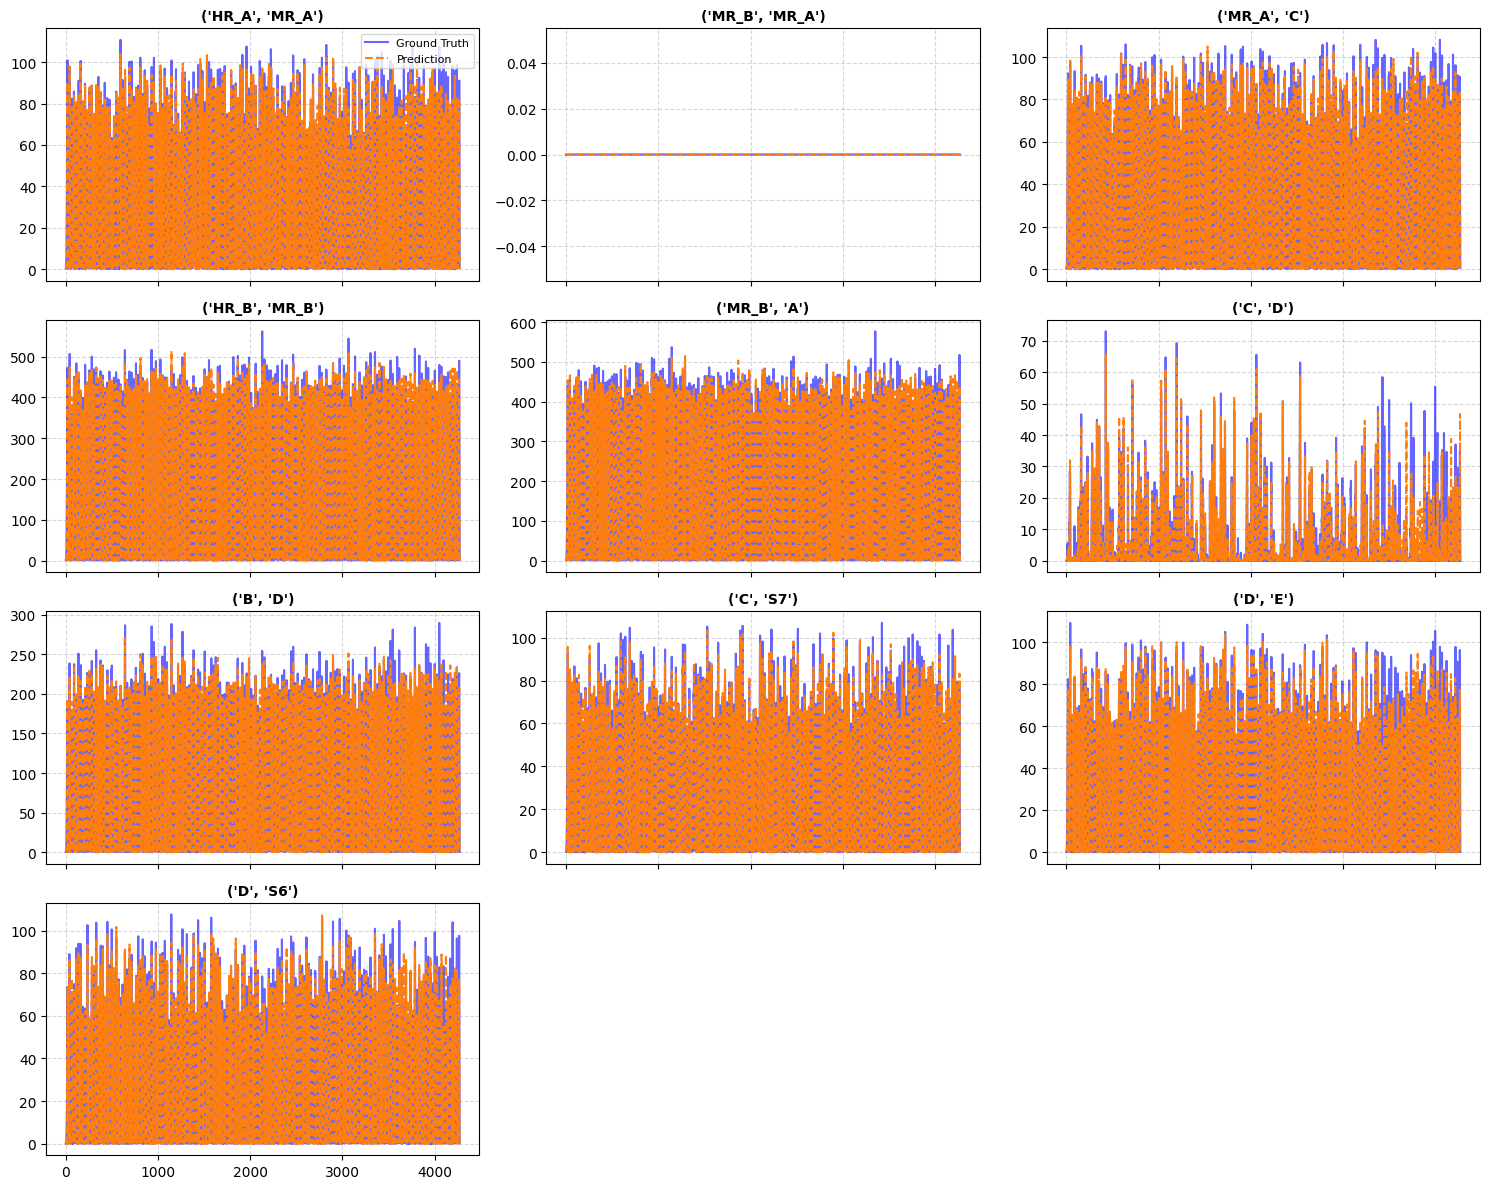


--- Validation Error per Channel (Gbps) ---
Channel 0: 1.48
Channel 1: 0.00
Channel 2: 1.48
Channel 3: 7.51
Channel 4: 7.55
Channel 5: 0.45
Channel 6: 3.71
Channel 7: 1.34
Channel 8: 1.35
Channel 9: 1.37
Channel 10: 1.35
Channel 11: 5.00
Channel 12: 1.35
Channel 13: 1.35
Channel 14: 1.37
Channel 15: 1.34


array([1.4830674, 0.       , 1.4801648, 7.514859 , 7.5463033, 0.4546291,
       3.7069757, 1.3443327, 1.3498   , 1.3679048, 1.3519204, 5.001516 ,
       1.3494349, 1.350242 , 1.3684586, 1.3438172], dtype=float32)

In [225]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import numpy as np
import math

def plot_all_channels_grid(trues, preds, timestamps=None, channel_names=None, max_channels=12):
    """
    Plots the Ground Truth vs Prediction for multiple channels in a grid.
    
    Args:
        trues: Numpy array of actual traffic [Time_Steps, Num_Nodes].
        preds: Numpy array of predicted traffic [Time_Steps, Num_Nodes].
        timestamps: (Optional) Array of datetime objects for the x-axis.
        channel_names: (Optional) List of names for each node.
        max_channels: The maximum number of channels to plot (to prevent memory crash).
    """
    num_nodes = trues.shape[1]
    
    # Cap the number of channels to plot
    nodes_to_plot = min(num_nodes, max_channels)
    
    # Determine grid size (e.g., 12 plots = 4 rows x 3 columns)
    cols = 3
    rows = math.ceil(nodes_to_plot / cols)
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), sharex=True)
    axes = axes.flatten() # Flatten so we can iterate easily
    
    # Generate X-axis (Use timestamps if provided, otherwise use step index)
    if timestamps is not None:
        x_axis = timestamps
    else:
        x_axis = np.arange(trues.shape[0])

    print(f"Plotting {nodes_to_plot} channels...")

    for i in range(nodes_to_plot):
        ax = axes[i]
        
        # Plot Truth and Prediction
        ax.plot(x_axis, trues[:, i], label='Ground Truth', color='blue', alpha=0.6, linewidth=1.5)
        ax.plot(x_axis, preds[:, i], label='Prediction', color='#ff7f0e', linestyle='--', linewidth=1.5)
        
        # Title and Labels
        ch_name = channel_names[i] if channel_names is not None else f"Channel {i}"
        ax.set_title(ch_name, fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to save space
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

    # Format the X-axis for dates if timestamps are provided
    if timestamps is not None:
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Hide any unused subplots (if nodes_to_plot is not a multiple of cols)
    for j in range(nodes_to_plot, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



def validate(model, val_loader, criterion, device, plot=False, channel_names=None, max_channels=12):
    """
    Evaluates the model on the Validation Set.
    Returns the average validation loss.
    If plot=True, it will generate a grid chart of predictions vs. ground truth.
    """
    model.eval() # Set model to evaluation mode
    total_val_loss = 0.0
    
    # Lists to store batch results for plotting
    all_preds = []
    all_trues = []
    
    with torch.no_grad(): # Disable gradient calculation
        for X, TE, Y in val_loader:
            X = X.to(device)
            TE = TE.to(device)
            Y = Y.to(device)
            
            # Forward pass
            Y_pred = model(X, TE)
            
            # Calculate loss
            loss = criterion(Y_pred, Y)
            total_val_loss += loss.item() * X.size(0) # Multiply by batch size
            
            # Store predictions for plotting (We take the first prediction step [:, 0, :, 0])
            if plot:
                all_preds.append(Y_pred[:, 0, :, 0].cpu().numpy())
                all_trues.append(Y[:, 0, :, 0].cpu().numpy())
            
    # Calculate average loss over all validation samples
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    
    # --- PLOTTING LOGIC ---
    if plot:
        print("\n📊 Generating Validation Plots...")
        # 1. Concatenate all batches chronologically
        final_preds_scaled = np.concatenate(all_preds, axis=0)
        final_trues_scaled = np.concatenate(all_trues, axis=0)
        
        # 2. Denormalize to get real Gbps
        final_preds = (final_preds_scaled * val_loader.dataset.std) + val_loader.dataset.mean
        final_trues = (final_trues_scaled * val_loader.dataset.std) + val_loader.dataset.mean
        
        # Force negative predictions to 0
        final_preds = np.maximum(final_preds, 0)
        
        # 3. Call the plotting function
        plot_all_channels_grid(
            trues=final_trues, 
            preds=final_preds, 
            channel_names=channel_names, 
            max_channels=max_channels
        )

    # Calculate real Gbps MAE per channel
    real_val_loss = avg_val_loss * val_loader.dataset.std

    print("\n--- Validation Error per Channel (Gbps) ---")
    for i in range(len(real_val_loss)):
        print(f"Channel {i}: {real_val_loss[i]:.2f}")
        
    return real_val_loss

VAL_TSS_DS = NetworkTrafficDataset(
    dataframe=DATA_RAW_MODEL, 
    num_his=HIST_STEPS, 
    num_pred=PRED_STEPS, 
    time_slot_hours=FREQ_H,
    mean=TSS_TRAIN_DS.mean,
    std=TSS_TRAIN_DS.std,
    )

VAL_TSS_DL = DataLoader(VAL_TSS_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

MODEL = GMAN(
        node_vectors,
        config
).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

validate(MODEL, VAL_TSS_DL,nn.MSELoss(), device, plot=True, channel_names=DATA_RAW_MODEL.columns, max_channels=10)


In [116]:
list(VAL_TSS_DL)[0][0].shape

torch.Size([32, 24, 16, 1])

# PREDICTION

In [117]:


PRED_TSS_DS = NetworkTrafficDataset(
    dataframe=pred_data, 
    num_his=HIST_STEPS, 
    num_pred=PRED_STEPS, 
    time_slot_hours=FREQ_H,
    mean=TSS_TRAIN_DS.mean,
    std=TSS_TRAIN_DS.std,
    is_inference=True
    )

print(f"length of PRED_TSS_DS: {len(PRED_TSS_DS)}")
X, TE = PRED_TSS_DS[0]
X = X.unsqueeze(0)
TE = TE.unsqueeze(0)

print(f"X shape: {X.shape}")
print(f"TE shape: {TE.shape}")

length of PRED_TSS_DS: 1
X shape: torch.Size([1, 24, 16, 1])
TE shape: torch.Size([1, 24, 3])


In [180]:
def prediction(model, data:pd.DataFrame, dataset_obj, device='cpu'):

    model.eval()
    model.to(device)
    _dates_pred = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=PRED_STEPS, freq='h')
    
    _pred_ds = NetworkTrafficDataset(
                    dataframe=data, 
                    num_his=HIST_STEPS, 
                    num_pred=PRED_STEPS, 
                    time_slot_hours=FREQ_H,
                    mean=dataset_obj.mean,
                    std=dataset_obj.std,
                    is_inference=False
                )

    _pred_dl = DataLoader(_pred_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    with torch.no_grad():
        
        for X, TE,Y in _pred_dl:
            pass


        X = X[-1:].to(device)
        TE = TE[-1:].to(device)
        
        _pred = model(X, TE)
    
    _pred = dataset_obj.reverse_transform(_pred)

    _pred_df = pd.DataFrame(_pred[-1].squeeze(-1), index=_dates_pred, columns=data.columns)

    return _pred_df


MODEL = GMAN(
        node_vectors,
        config
)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

PRED_DATA = DATA_RAW_MODEL.copy()
last_timestamp = PRED_DATA.index[-1]

print(f"the last timestamp is {last_timestamp}")
DAYS_PREDICT = 5

for _ in range(DAYS_PREDICT):

    print(f"Predicting day {_}")
    PRED_DATA = pd.concat([
        PRED_DATA, 
        prediction(MODEL, PRED_DATA, TSS_TRAIN_DS)
        ], axis=0)

    


Retrieving model from timeseries_GMAN_model.pth
the last timestamp is 2024-06-28 23:00:00
Predicting day 0
Predicting day 1
Predicting day 2
Predicting day 3
Predicting day 4


In [184]:
PRED_DATA = PRED_DATA[PRED_DATA.index > last_timestamp]

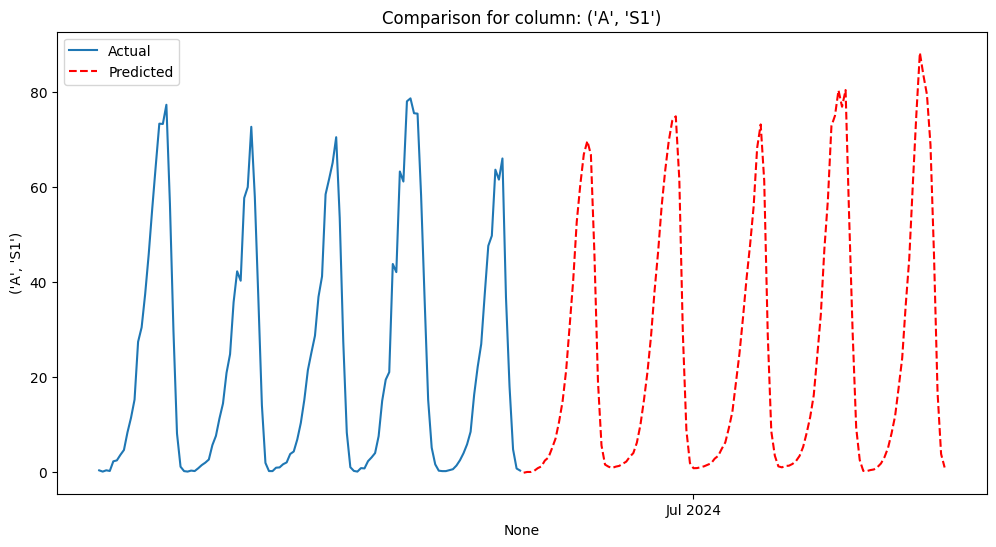

In [209]:
import random
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

column = random.choice(PRED_DATA.columns)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column].index, y=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column], label='Actual', ax=ax)
sns.lineplot(x=PRED_DATA.index, y=PRED_DATA[column], label='Predicted', color='red', linestyle='--', ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


plt.title(f"Comparison for column: {column}")
plt.legend()    
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Set the style for a nice looking plot
sns.set_theme(style="darkgrid")

# 2. Create the figure and axis
plt.figure(figsize=(12, 6))

# 3. Plot using the index for the x-axis
sns.lineplot(data=df, x=df.index, y="traffic_volume")

# 4. Format the plot
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.show()